In [3]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [4]:
df_main = pd.read_pickle('data_files/df_main.pkl')

In [5]:
# Creating a df with only relevant features for modelling
df_ml = df_main.drop(['Season', 'Player', 'Tm', 'First', 'Rank', 'Pts Won', 'Pts Max'], axis=1)

In [6]:
df_ml

,Age,Share,G,MP,PTS,TRB,AST,STL,BLK,FG%,3P%,FT%,W,L,W/L%,PS/G,PA/G,Conference Ranking,Attempts_3P
0,27,0.991,82,39.4,24.2,13.9,5.0,1.5,2.2,0.499,0.256,0.791,58.0,24.0,0.707,94.5,89.1,1.0,1
1,27,0.582,69,36.6,22.3,12.4,3.1,0.9,2.7,0.501,0.167,0.599,57.0,25.0,0.695,91.5,84.3,2.0,1
2,25,0.425,78,35.7,20.1,10.0,2.1,0.8,2.6,0.434,0.111,0.757,61.0,21.0,0.744,91.4,85.6,1.0,1
3,26,0.228,81,40.3,24.2,6.3,2.1,1.3,0.2,0.480,0.433,0.927,55.0,27.0,0.671,102.8,97.8,4.0,1
4,25,0.172,65,37.6,24.0,5.5,5.1,1.7,0.4,0.438,0.327,0.852,56.0,26.0,0.683,98.2,94.3,3.0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
279,27,0.143,77,35.4,28.7,3.6,6.7,0.9,0.2,0.479,0.401,0.847,50.0,32.0,0.610,112.8,108.2,2.0,1
280,25,0.087,74,35.7,26.9,8.1,4.9,1.0,0.6,0.471,0.376,0.833,64.0,18.0,0.780,120.6,109.2,1.0,1
281,22,0.018,79,35.1,25.9,5.4,5.1,1.3,0.5,0.461,0.357,0.836,56.0,26.0,0.683,113.0,106.5,3.0,1
282,27,0.003,82,35.7,19.4,13.7,8.2,0.9,0.6,0.594,0.379,0.704,46.0,36.0,0.561,116.6,114.8,9.0,1


In [20]:
# train-test split
from sklearn.model_selection import train_test_split

X = df_ml.drop('Share', axis=1)
y = df_ml['Share']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [22]:
# Model training
import xgboost
from xgboost import XGBRegressor

model = XGBRegressor()
model.fit(X_train, y_train)


XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=None, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=None,
             n_jobs=None, num_parallel_tree=None, ...)

In [23]:
# predictions
y_pred = model.predict(X_test)

In [24]:
# evaluation
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"MSE: {mse:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"MAE: {mae:.4f}")
print(f"R² Score: {r2:.4f}")


MSE: 0.0488
RMSE: 0.2210
MAE: 0.1362
R² Score: 0.4268


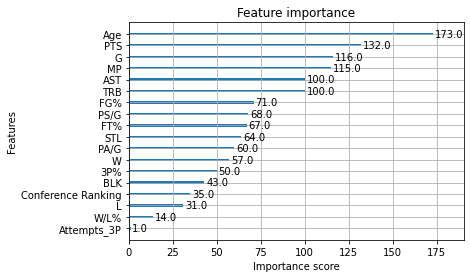

In [25]:
# feature importance

xgboost.plot_importance(model)
plt.show()

NameError: name 'y_pred' is not defined